Я работаю в гугл колабе. Код в файлах .py был сделан в visual studio, и файлы с ним помещены на мой гугл диск. Так что ячейку ниже можно не воспроизводить

In [1]:
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/calorie_project

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/calorie_project


##**EDA: предсказание калорийности блюд**


###Импорты и настройик

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import Counter

# стиль графиков и размер фигур
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 110

# фиксируем seed для воспроизводимости
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [3]:
DATA_DIR = "data"

dish = pd.read_csv(os.path.join(DATA_DIR, "dish.csv"))
ingredients = pd.read_csv(os.path.join(DATA_DIR, "ingredients.csv"))

print("Размер dish:", dish.shape)
print("Размер ingredients:", ingredients.shape)
dish.head()

Размер dish: (3262, 5)
Размер ingredients: (555, 2)


,dish_id,total_calories,total_mass,ingredients,split
0,dish_1561662216,300.794281,193.0,ingr_0000000508;ingr_0000000122;ingr_000000002...,test
1,dish_1561662054,419.438782,292.0,ingr_0000000312;ingr_0000000026;ingr_000000002...,train
2,dish_1562008979,382.936646,290.0,ingr_0000000448;ingr_0000000520;ingr_000000046...,test
3,dish_1560455030,20.590000,103.0,ingr_0000000471;ingr_0000000031;ingr_0000000347,train
4,dish_1558372433,74.360001,143.0,ingr_0000000453,train


In [4]:
print("Информация о dish")
dish.info()

print("\nПропуски в dish:")
print(dish.isna().sum())

print("\nИнформация об imgredients")
ingredients.info()

print("\nПропуски в ingredients:")
print(ingredients.isna().sum())

Информация о dish
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3262 entries, 0 to 3261
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   dish_id         3262 non-null   object 
 1   total_calories  3262 non-null   float64
 2   total_mass      3262 non-null   float64
 3   ingredients     3262 non-null   object 
 4   split           3262 non-null   object 
dtypes: float64(2), object(3)
memory usage: 127.6+ KB

Пропуски в dish:
dish_id           0
total_calories    0
total_mass        0
ingredients       0
split             0
dtype: int64

Информация об imgredients
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555 entries, 0 to 554
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      555 non-null    int64 
 1   ingr    555 non-null    object
dtypes: int64(1), object(1)
memory usage: 8.8+ KB

Пропуски в ingredients:
id      0
ingr    0
dtype:

### Целевая переменная калорийности и масса порции

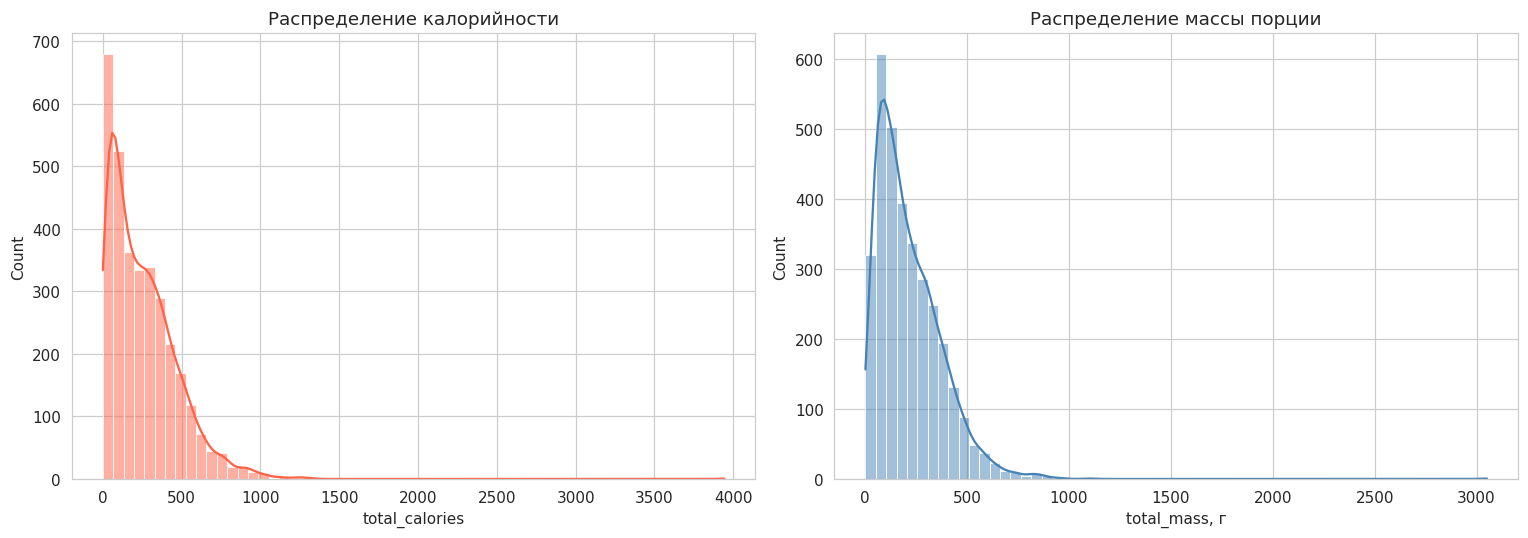

Статистика total_calories:
count    3262.000000
mean      255.012738
std       219.637570
min         0.000000
25%        80.114996
50%       209.110062
75%       375.122963
max      3943.325195
Name: total_calories, dtype: float64

Статистика total_mass:
count    3262.000000
mean      214.980074
std       161.497428
min         1.000000
25%        92.000000
50%       177.000000
75%       305.000000
max      3051.000000
Name: total_mass, dtype: float64


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(dish["total_calories"], bins=60, kde=True, ax=axes[0], color="tomato")
axes[0].set_title("Распределение калорийности")
axes[0].set_xlabel("total_calories")

sns.histplot(dish["total_mass"], bins=60, kde=True, ax=axes[1], color="steelblue")
axes[1].set_title("Распределение массы порции")
axes[1].set_xlabel("total_mass, г")

plt.tight_layout()
plt.show()

print("Статистика total_calories:")
print(dish["total_calories"].describe())

print("\nСтатистика total_mass:")
print(dish["total_mass"].describe())

Значения split: ['test' 'train']

Количество записей по сплитам:
split
train    2755
test      507
Name: count, dtype: int64


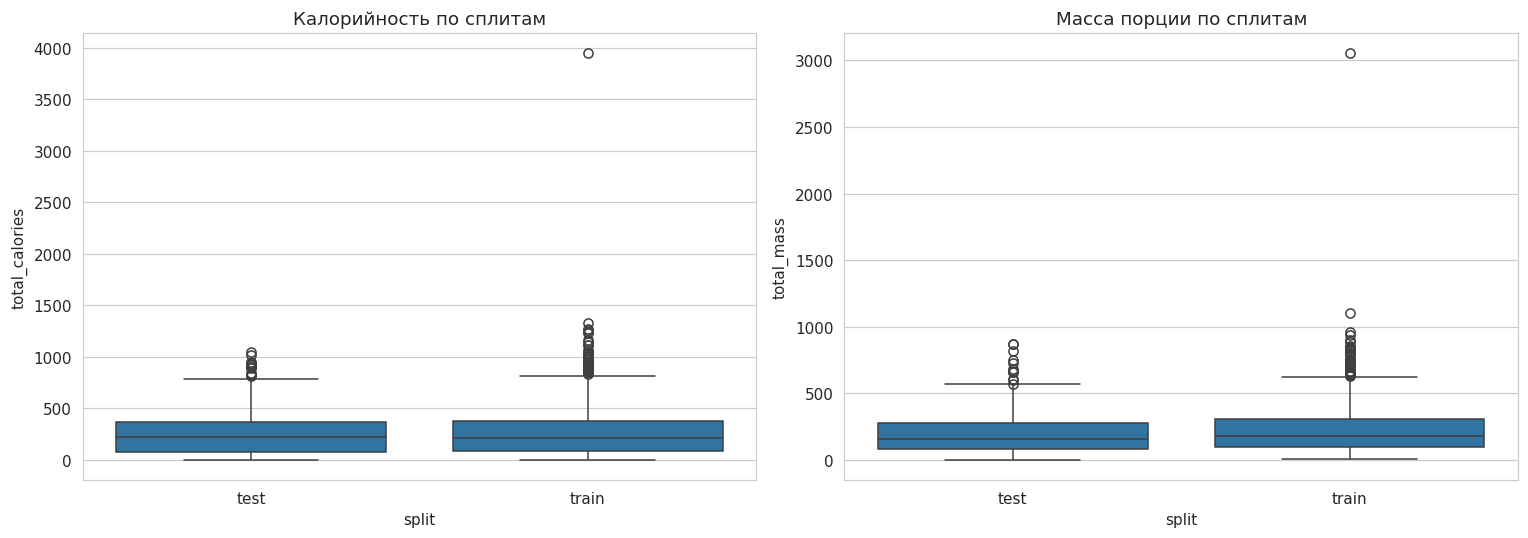

In [6]:
print("Значения split:", dish["split"].unique())
print("\nКоличество записей по сплитам:")
print(dish["split"].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=dish, x="split", y="total_calories", ax=axes[0])
axes[0].set_title("Калорийность по сплитам")

sns.boxplot(data=dish, x="split", y="total_mass", ax=axes[1])
axes[1].set_title("Масса порции по сплитам")

plt.tight_layout()
plt.show()

### Примеры изображений

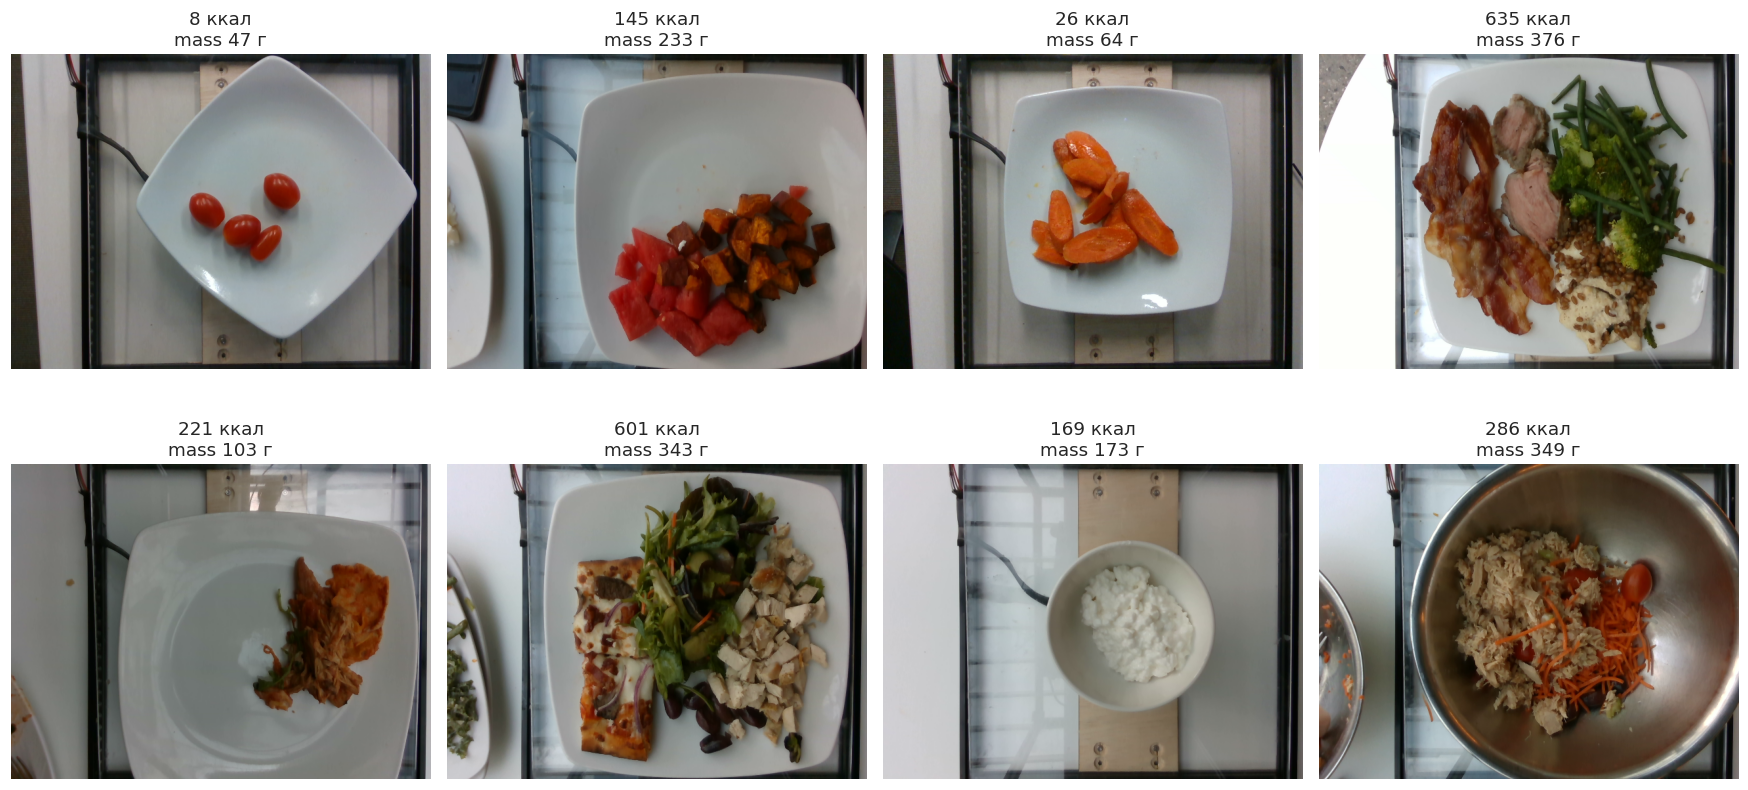

In [7]:
def load_dish_image(dish_id, data_dir=DATA_DIR):
    """Загружает rgb.png по dish_id и возвращает PIL.Image."""
    img_path = os.path.join(data_dir, "images", str(dish_id), "rgb.png")
    if not os.path.exists(img_path):
        return None
    return Image.open(img_path).convert("RGB")


# хочу посмотреть случайные 8 блюд из train
sample_df = dish[dish["split"] == "train"].sample(8, random_state=RANDOM_STATE).reset_index(drop=True)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, (_, row) in zip(axes.flat, sample_df.iterrows()):
    img = load_dish_image(row["dish_id"])
    if img is None:
        ax.set_title(f"нет фото\ndish_id {row['dish_id']}")
        ax.axis("off")
        continue
    ax.imshow(img)
    ax.set_title(f"{int(row['total_calories'])} ккал\nmass {int(row['total_mass'])} г")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [8]:
def normalize_id(value):
    """Приводит id к целому: 'ingr_0000000122' -> 122."""
    return int(str(value).replace("ingr_", "").strip())

ingredients["id_norm"] = ingredients["id"].apply(normalize_id)

id_to_name = dict(zip(ingredients["id_norm"], ingredients["ingr"]))


def parse_ingredients_ids(raw):
    """Превращает строку 'ingr_0000000122;ingr_0000000026;..' в список целых id."""
    if pd.isna(raw):
        return []
    parts = [p for p in str(raw).split(";") if p.strip() not in ("", "..")]
    return [normalize_id(p) for p in parts]


def ids_to_names(raw):
    """Возвращает список названий ингредиентов или пустой список."""
    ids = parse_ingredients_ids(raw)
    return [id_to_name.get(i, f"unknown_{i}") for i in ids]


dish["ingredients_names"] = dish["ingredients"].apply(ids_to_names)
dish["ingredients_text"] = dish["ingredients_names"].apply(lambda x: ", ".join(x))

dish[["dish_id", "ingredients", "ingredients_text", "total_calories"]].head()

,dish_id,ingredients,ingredients_text,total_calories
0,dish_1561662216,ingr_0000000508;ingr_0000000122;ingr_000000002...,"soy sauce, garlic, white rice, parsley, onions...",300.794281
1,dish_1561662054,ingr_0000000312;ingr_0000000026;ingr_000000002...,"pepper, white rice, mixed greens, garlic, soy ...",419.438782
2,dish_1562008979,ingr_0000000448;ingr_0000000520;ingr_000000046...,"jalapenos, lemon juice, pork, wheat berry, cab...",382.936646
3,dish_1560455030,ingr_0000000471;ingr_0000000031;ingr_0000000347,"cherry tomatoes, cucumbers, baby carrots",20.590000
4,dish_1558372433,ingr_0000000453,deprecated,74.360001


Среднее число ингредиентов на блюдо: 7.31
Максимум ингредиентов: 34
Блюд с пустым списком ингредиентов: 0


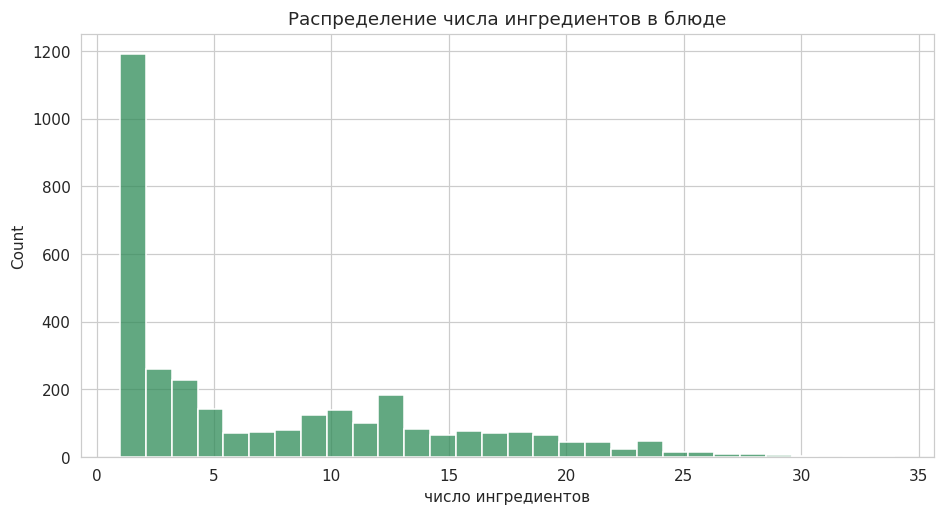

In [9]:
dish["n_ingredients"] = dish["ingredients_names"].apply(len)

print("Среднее число ингредиентов на блюдо:", round(dish["n_ingredients"].mean(), 2))
print("Максимум ингредиентов:", dish["n_ingredients"].max())
print("Блюд с пустым списком ингредиентов:", (dish["n_ingredients"] == 0).sum())

sns.histplot(dish["n_ingredients"], bins=30, color="seagreen")
plt.title("Распределение числа ингредиентов в блюде")
plt.xlabel("число ингредиентов")
plt.show()

### Топ-20 самых частых ингредиентов

/tmp/ipykernel_1341/3969606357.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top20, y="ingredient", x="count", palette="viridis")


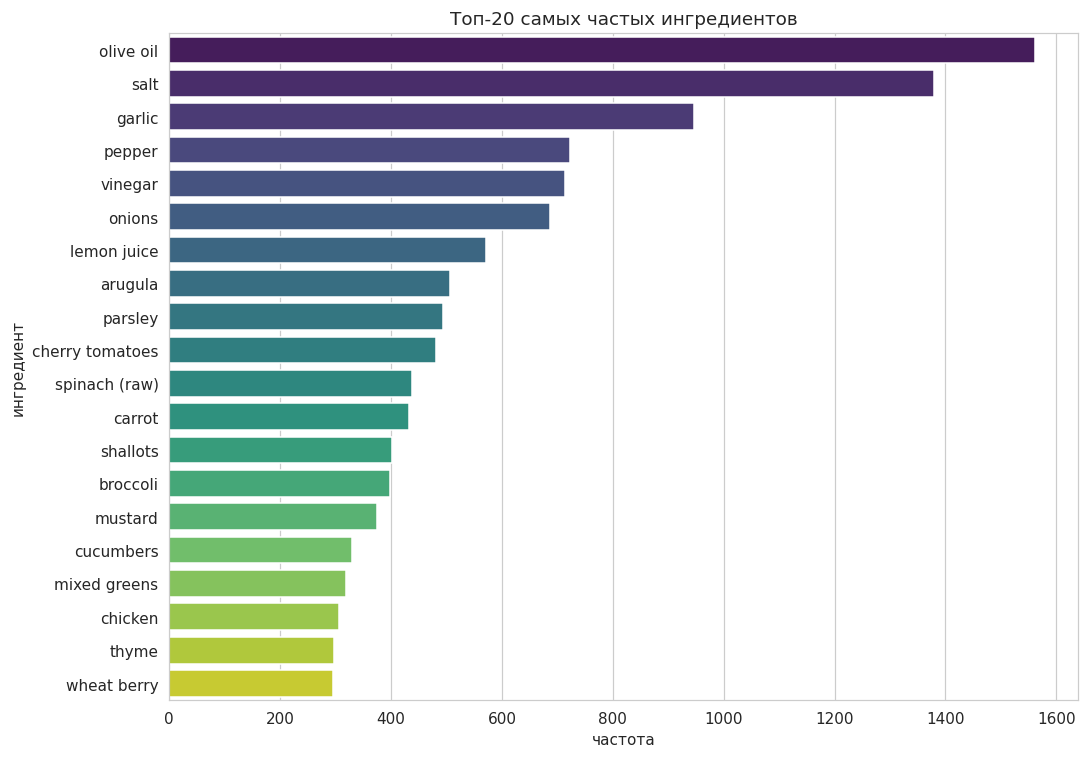

,ingredient,count
0,olive oil,1561
1,salt,1379
2,garlic,947
3,pepper,723
4,vinegar,713
5,onions,686
6,lemon juice,572
7,arugula,506
8,parsley,493
9,cherry tomatoes,481


In [10]:
all_ingredients = [name for lst in dish["ingredients_names"] for name in lst]
counter = Counter(all_ingredients)

top20 = pd.DataFrame(counter.most_common(20), columns=["ingredient", "count"])

plt.figure(figsize=(10, 7))
sns.barplot(data=top20, y="ingredient", x="count", palette="viridis")
plt.title("Топ-20 самых частых ингредиентов")
plt.xlabel("частота")
plt.ylabel("ингредиент")
plt.tight_layout()
plt.show()

top20

### Распределение калорий по сплитам train/test

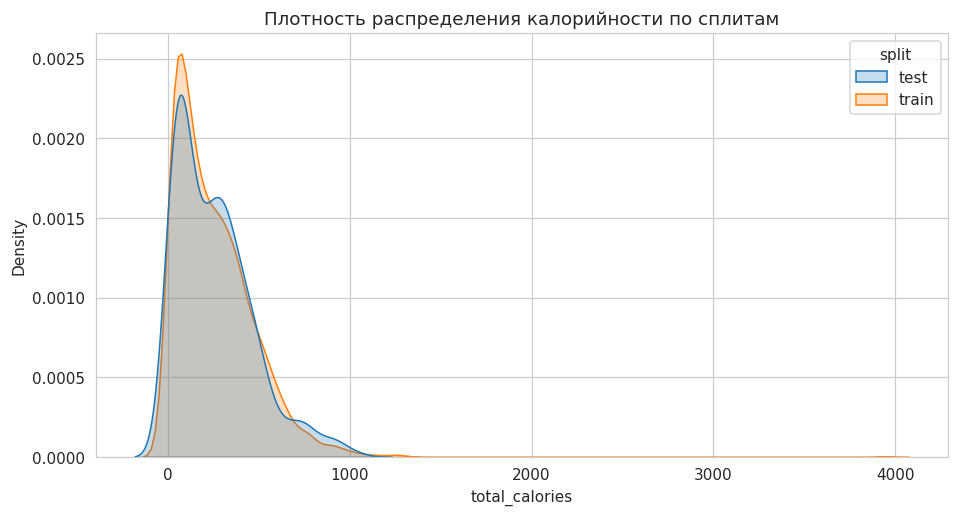

Средняя калорийность по сплитам:
             mean      median         std  count
split                                           
test   255.467051  226.014999  212.241674    507
train  254.929131  208.115997  221.009051   2755


In [11]:
plt.figure(figsize=(10, 5))
sns.kdeplot(data=dish, x="total_calories", hue="split", fill=True, common_norm=False)
plt.title("Плотность распределения калорийности по сплитам")
plt.xlabel("total_calories")
plt.show()

print("Средняя калорийность по сплитам:")
print(dish.groupby("split")["total_calories"].agg(["mean", "median", "std", "count"]))

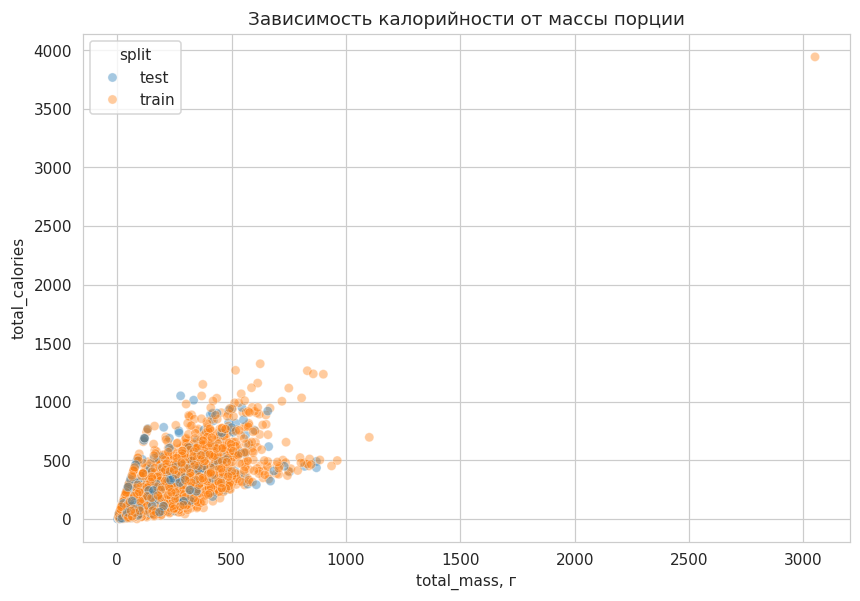

Корреляция Пирсона между total_mass и total_calories: 0.76


In [12]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=dish, x="total_mass", y="total_calories", hue="split", alpha=0.4)
plt.title("Зависимость калорийности от массы порции")
plt.xlabel("total_mass, г")
plt.ylabel("total_calories")
plt.show()

print("Корреляция Пирсона между total_mass и total_calories:",round(dish["total_mass"].corr(dish["total_calories"]), 3))

In [13]:
dish.head()

,dish_id,total_calories,total_mass,ingredients,split,ingredients_names,ingredients_text,n_ingredients
0,dish_1561662216,300.794281,193.0,ingr_0000000508;ingr_0000000122;ingr_000000002...,test,"[soy sauce, garlic, white rice, parsley, onion...","soy sauce, garlic, white rice, parsley, onions...",17
1,dish_1561662054,419.438782,292.0,ingr_0000000312;ingr_0000000026;ingr_000000002...,train,"[pepper, white rice, mixed greens, garlic, soy...","pepper, white rice, mixed greens, garlic, soy ...",17
2,dish_1562008979,382.936646,290.0,ingr_0000000448;ingr_0000000520;ingr_000000046...,test,"[jalapenos, lemon juice, pork, wheat berry, ca...","jalapenos, lemon juice, pork, wheat berry, cab...",13
3,dish_1560455030,20.590000,103.0,ingr_0000000471;ingr_0000000031;ingr_0000000347,train,"[cherry tomatoes, cucumbers, baby carrots]","cherry tomatoes, cucumbers, baby carrots",3
4,dish_1558372433,74.360001,143.0,ingr_0000000453,train,[deprecated],deprecated,1


In [14]:
deprecated_mask = dish["ingredients_names"].apply(lambda lst: "deprecated" in lst)
print("Блюд с 'deprecated':", deprecated_mask.sum())
print(dish.loc[deprecated_mask, "total_calories"].describe())

Блюд с 'deprecated': 31
count      31.000000
mean      230.255260
std       281.291034
min        12.300000
25%        74.099998
50%        74.879997
75%       261.757492
max      1148.250977
Name: total_calories, dtype: float64


In [15]:
def clean_names(lst):
    cleaned = [name for name in lst if name != "deprecated"]
    return cleaned if cleaned else ["unknown"]

dish["ingredients_names"] = dish["ingredients_names"].apply(clean_names)

In [16]:
dish["ingredients_text"] = dish["ingredients_names"].apply(lambda x: ", ".join(x))
dish["n_ingredients"] = dish["ingredients_names"].apply(len)

In [17]:
print("Пустых ingredients_text:", (dish["ingredients_text"].str.strip() == "").sum())
print("Среднее число ингредиентов теперь:", round(dish["n_ingredients"].mean(), 2))

Пустых ingredients_text: 0
Среднее число ингредиентов теперь: 7.31


In [18]:
all_names = [name for lst in dish["ingredients_names"] for name in lst]
counter = Counter(all_names)

# смотрим редкие токены чтобы найти что-то yfgjlj,bt depreciated или none
rare = [name for name, cnt in counter.items() if cnt <= 2]
print("Редких ингредиентов (<= 2 вхождений):", len(rare))
print(sorted(rare)[:50])

Редких ингредиентов (<= 2 вхождений): 16
['balsamic vinegar', 'banana with peel', 'bread', 'brown sugar', 'cod', 'fruit salad', 'ice cream cones', 'mozzarella cheese', 'orange with peel', 'pasta salad', 'pepperoni', 'plate only', 'succotash', 'syrup', 'toast', 'wheat bread']


In [19]:
dish.to_csv("data/dish_prepared.csv", index=False)

## Обучение модели

In [20]:
!pip install -q albumentations timm transformers torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 23.1 MB/s eta 0:00:00


In [21]:
import sys
import torch


if "scripts" not in sys.path:
    sys.path.append("scripts")

from config import Config
from dataset import get_loaders
from utils import train, DishCalorieModel, set_seed

In [22]:
print("torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Device name:", torch.cuda.get_device_name(0))
    !nvidia-smi
else:
    print("GPU не найден - можно плакать")

torch: 2.11.0+cu130
CUDA available: True
Device name: Tesla T4
Sun Oct  4 13:21:58 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   47C    P8             14W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |         

In [23]:
cfg = Config()
cfg.DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

os.makedirs(cfg.CHECKPOINT_DIR, exist_ok=True)

print(cfg)

Config(DATA_DIR='data', PREPARED_CSV='dish_prepared.csv', CHECKPOINT_DIR='checkpoints', MODEL_SAVE_PATH='checkpoints/best_model.pth', IMAGE_SIZE=224, MAX_LEN=64, NUM_WORKERS=2, TEXT_MODEL_NAME='distilbert-base-uncased', IMAGE_MODEL_NAME='resnet18', TEXT_EMBED_DIM=768, IMAGE_EMBED_DIM=512, PROJECTION_DIM=256, DROPOUT=0.2, SEED=42, BATCH_SIZE=4, NUM_EPOCHS=25, PATIENCE=5, TEXT_LR=2e-05, IMAGE_LR=1e-05, CLASSIFIER_LR=0.001, WEIGHT_DECAY=0.01, UNFREEZE_TEXT_ENCODER=True, UNFREEZE_IMAGE_ENCODER=False, SAVE_BEST_ONLY=True, LOG_EVERY_N_STEPS=50, DEVICE='cuda', MAX_GRAD_NORM=1.0)


In [24]:
train_loader, test_loader, tokenizer = get_loaders(cfg)
batch = next(iter(train_loader))

print("Размеры батча:")
for k, v in batch.items():
    print(f"  {k}: {tuple(v.shape)}  dtype={v.dtype}")

print("\nПример текста (декодированный):")
print(tokenizer.decode(batch["input_ids"][0], skip_special_tokens=True))

print("\nTargets:", batch["target"])

Train примеров: 2755  Test примеров: 507


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Размеры батча:
  image: (4, 3, 224, 224)  dtype=torch.float32
  input_ids: (4, 64)  dtype=torch.int64
  attention_mask: (4, 64)  dtype=torch.int64
  mass: (4,)  dtype=torch.float32
  target: (4,)  dtype=torch.float32

Пример текста (декодированный):
pork, pepper, white rice, soy sauce, garlic, bok choy, salt, sugar

Targets: tensor([2.0615, 0.9981, 0.4100, 0.1800])


In [25]:
model, history = train(cfg)

Устройство: cuda
Train примеров: 2755  Test примеров: 507
Train батчей: 688  Test батчей: 127


model.safetensors: reconstructing file:   0%|          |  0.00B / 46.8MB            

model.safetensors: downloading bytes:           |  0.00B            

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Обучаемых параметров: 66,822,657 из 77,999,169

Эпоха 1/25
  step 50/688  loss 54.31
  step 100/688  loss 69.93
  step 150/688  loss 164.79
  step 200/688  loss 49.66
  step 250/688  loss 26.41
  step 300/688  loss 68.49
  step 350/688  loss 184.31
  step 400/688  loss 37.09
  step 450/688  loss 61.67
  step 500/688  loss 43.64
  step 550/688  loss 115.44
  step 600/688  loss 88.85
  step 650/688  loss 33.41
  train loss 80.95  train MAE 80.95  | test loss 59.84  test MAE 59.92  | lr 9.96e-04
  чекпоинт сохранён: checkpoints/best_model.pth  (MAE 59.92)

Эпоха 2/25
  step 50/688  loss 30.64
  step 100/688  loss 55.44
  step 150/688  loss 46.61
  step 200/688  loss 67.65
  step 250/688  loss 22.06
  step 300/688  loss 41.18
  step 350/688  loss 14.86
  step 400/688  loss 48.06
  step 450/688  loss 57.73
  step 500/688  loss 111.72
  step 550/688  loss 60.26
  step 600/688  loss 86.60
  step 650/688  loss 30.61
  train loss 58.79  train MAE 58.79  | test loss 50.00  test MAE 50.08  | lr 9

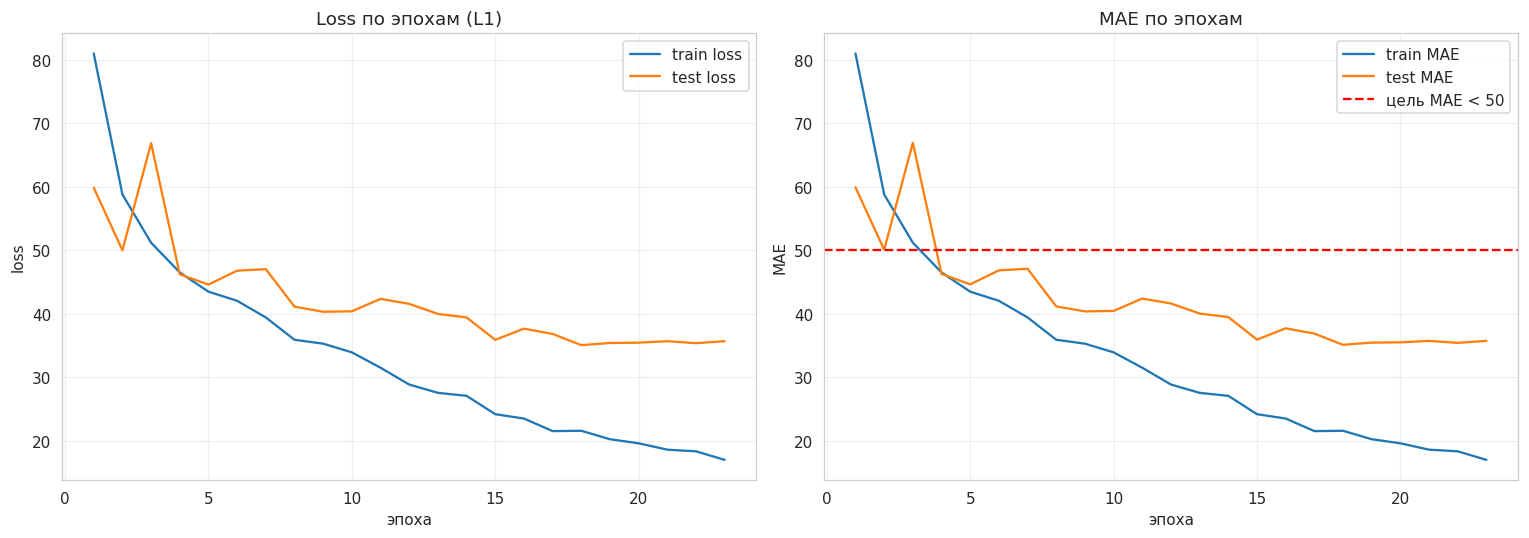

In [26]:
epochs = range(1, len(history["train_mae"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs, history["train_loss"], label="train loss")
axes[0].plot(epochs, history["test_loss"], label="test loss")
axes[0].set_title("Loss по эпохам (L1)")
axes[0].set_xlabel("эпоха")
axes[0].set_ylabel("loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs, history["train_mae"], label="train MAE")
axes[1].plot(epochs, history["test_mae"], label="test MAE")
axes[1].axhline(y=50, color="red", linestyle="--", label="цель MAE < 50")
axes[1].set_title("MAE по эпохам")
axes[1].set_xlabel("эпоха")
axes[1].set_ylabel("MAE")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [27]:
## Этап 4. Валидация обученной модели

In [28]:
from torch.utils.data import DataLoader
from torchmetrics import MeanAbsoluteError, MeanSquaredError, R2Score

In [29]:
cfg = Config()
cfg.DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
device = torch.device(cfg.DEVICE)

ckpt = torch.load(cfg.MODEL_SAVE_PATH, map_location=device, weights_only=False)
print("Эпоха лучшего чекпоинта:", ckpt["epoch"])
print("Best MAE в чекпоинте:", round(ckpt["best_mae"], 2))

Эпоха лучшего чекпоинта: 18
Best MAE в чекпоинте: 35.13


In [40]:
from torch.utils.data import DataLoader
from torchmetrics import MeanAbsoluteError, MeanSquaredError, R2Score
from transformers import AutoTokenizer

from dataset import DishDataset, build_transforms
from utils import DishCalorieModel
# у меня сбились импорты

In [32]:
df = pd.read_csv(os.path.join(cfg.DATA_DIR, cfg.PREPARED_CSV))
df["ingredients_text"] = df["ingredients_text"].fillna("unknown")
df["total_mass"] = df["total_mass"].clip(lower=1e-3)

test_df = df[df["split"] == "test"].reset_index(drop=True)
print(f"Test примеров: {len(test_df)}")

tokenizer = AutoTokenizer.from_pretrained(cfg.TEXT_MODEL_NAME)
test_transform = build_transforms(cfg.IMAGE_SIZE, is_train=False)

test_ds = DishDataset(
    dataframe=test_df,
    tokenizer=tokenizer,
    transform=test_transform,
    image_size=cfg.IMAGE_SIZE,
    max_len=cfg.MAX_LEN,
    data_dir=cfg.DATA_DIR,
)

test_loader = DataLoader(
    test_ds,
    batch_size=cfg.BATCH_SIZE,
    shuffle=False,
    num_workers=cfg.NUM_WORKERS,
    pin_memory=True,
)

print(f"Test батчей: {len(test_loader)}")

Test примеров: 507
Test батчей: 127


In [33]:
@torch.no_grad()
def predict(model, loader, device):
    """Прогоняет модель, возвращает абсолютные калории (pred и true)."""
    all_preds = []
    all_targets = []

    for batch in loader:
        image = batch["image"].to(device, non_blocking=True)
        input_ids = batch["input_ids"].to(device, non_blocking=True)
        attention_mask = batch["attention_mask"].to(device, non_blocking=True)
        mass = batch["mass"].to(device, non_blocking=True)
        target_per_g = batch["target"].to(device, non_blocking=True)

        # Модель возвращает cal/g, умножаем на массу — получаем абсолютные калории
        pred_per_g = model(image, input_ids, attention_mask)
        pred_cal = pred_per_g * mass
        target_cal = target_per_g * mass

        all_preds.append(pred_cal.cpu())
        all_targets.append(target_cal.cpu())

    preds = torch.cat(all_preds).numpy()
    targets = torch.cat(all_targets).numpy()
    return preds, targets


preds, targets = predict(model, test_loader, device)
print("Предсказаний собрано:", len(preds))

Предсказаний собрано: 507


In [34]:
mae = MeanAbsoluteError()(torch.tensor(preds), torch.tensor(targets)).item()
rmse = MeanSquaredError(squared=False)(torch.tensor(preds), torch.tensor(targets)).item()
r2 = R2Score()(torch.tensor(preds), torch.tensor(targets)).item()

print(f"MAE:  {mae:.2f} ккал")
print(f"RMSE: {rmse:.2f} ккал")
print(f"R2:   {r2:.3f}")
print()
if mae < 50:
    print("Целевая метрика MAE < 50 достигнута.")
else:
    print("MAE выше целевого значения.")

MAE:  35.76 ккал
RMSE: 69.01 ккал
R2:   0.894

Целевая метрика MAE < 50 достигнута.


In [ ]:
## Топ-5 блюд с наибольшей абсолютной ошибкой

In [35]:
results = test_df.copy()
results["predicted_calories"] = preds
results["abs_error"] = np.abs(preds - targets)
results = results.sort_values("abs_error", ascending=False).reset_index(drop=True)

top5 = results.head(5).copy()
top5[["dish_id", "total_calories", "predicted_calories", "abs_error"]]

,dish_id,total_calories,predicted_calories,abs_error
0,dish_1558720236,887.823059,408.987701,478.835358
1,dish_1558630325,751.541992,305.050629,446.491364
2,dish_1565811139,902.200012,559.037598,343.162415
3,dish_1566328831,941.609985,599.240723,342.369263
4,dish_1566328805,927.809998,593.444336,334.365662


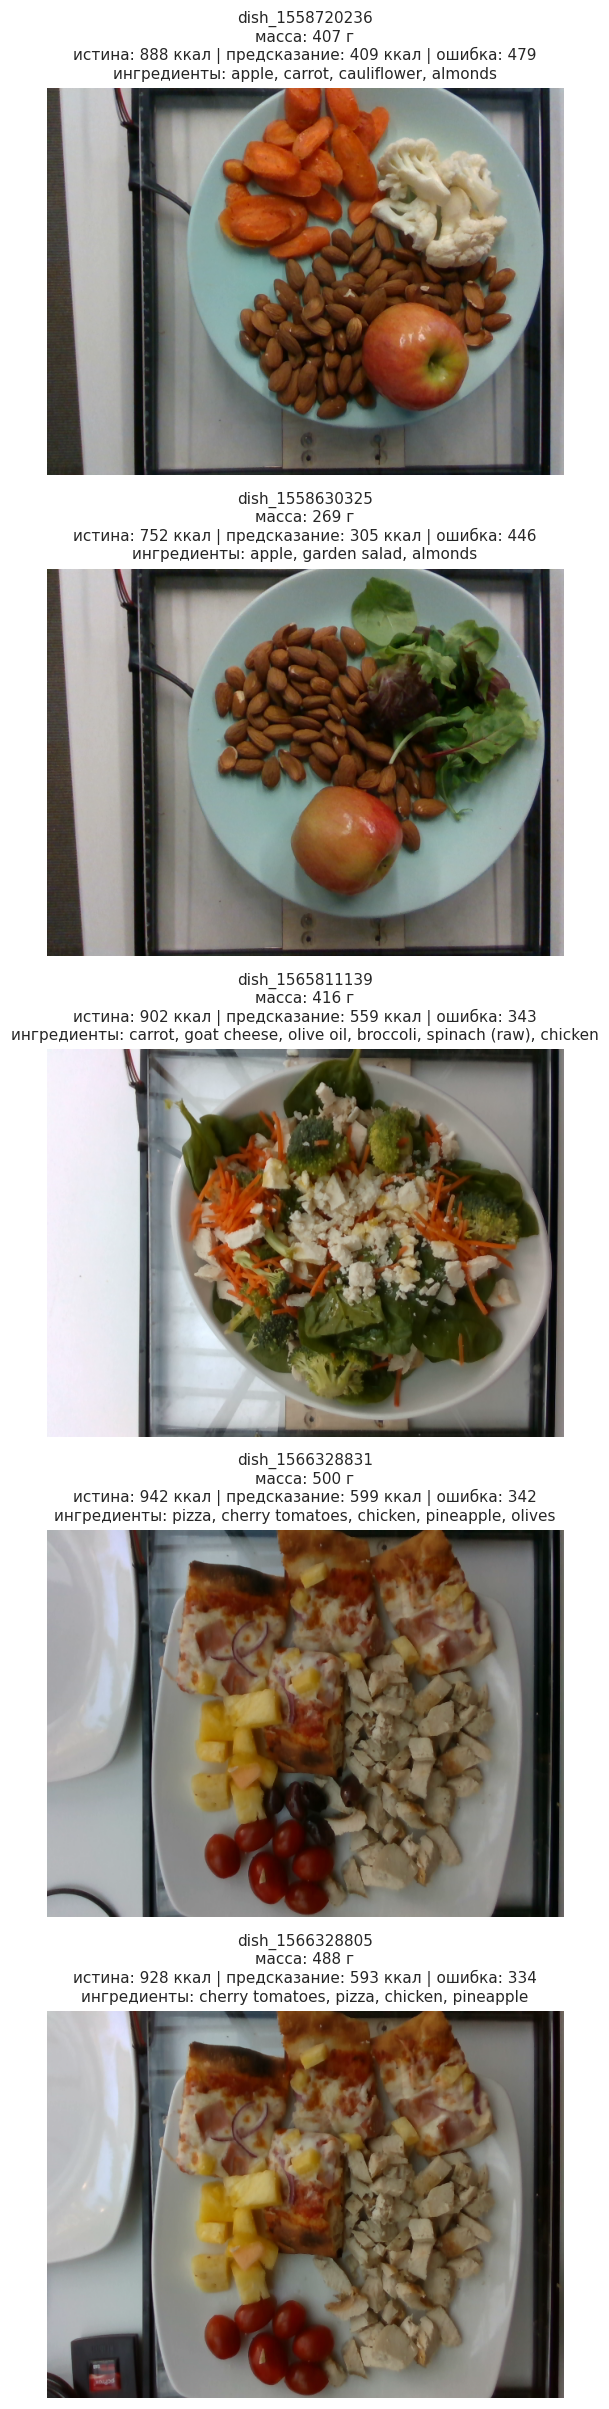

In [37]:
def load_dish_image(dish_id, data_dir):
    """Загружает фото блюда по dish_id."""
    img_path = os.path.join(data_dir, "images", str(dish_id), "rgb.png")
    if not os.path.exists(img_path):
        return None
    return Image.open(img_path).convert("RGB")


fig, axes = plt.subplots(5, 1, figsize=(10, 22))

for ax, (_, row) in zip(axes, top5.iterrows()):
    img = load_dish_image(row["dish_id"], cfg.DATA_DIR)
    if img is not None:
        ax.imshow(img)
    else:
        ax.text(0.5, 0.5, "нет изображения", ha="center", va="center")
        ax.axis("off")

    ingredients = row["ingredients_text"]
    true_cal = row["total_calories"]
    pred_cal = row["predicted_calories"]
    err = row["abs_error"]
    mass = row["total_mass"]

    title = (
        f"{row['dish_id']}\n"
        f"масса: {mass:.0f} г\n"
        f"истина: {true_cal:.0f} ккал | предсказание: {pred_cal:.0f} ккал | ошибка: {err:.0f}\n"
        f"ингредиенты: {ingredients}"
    )
    ax.set_title(title, fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [38]:
for i, (_, row) in enumerate(top5.iterrows(), 1):
    print(f"--- Пример {i} ---")
    print(f"dish_id: {row['dish_id']}")
    print(f"масса: {row['total_mass']:.0f} г")
    print(f"истина: {row['total_calories']:.1f} ккал")
    print(f"предсказание: {row['predicted_calories']:.1f} ккал")
    print(f"абсолютная ошибка: {row['abs_error']:.1f} ккал")
    print(f"ингредиенты: {row['ingredients_text']}")

--- Пример 1 ---
dish_id: dish_1558720236
масса: 407 г
истина: 887.8 ккал
предсказание: 409.0 ккал
абсолютная ошибка: 478.8 ккал
ингредиенты: apple, carrot, cauliflower, almonds
--- Пример 2 ---
dish_id: dish_1558630325
масса: 269 г
истина: 751.5 ккал
предсказание: 305.1 ккал
абсолютная ошибка: 446.5 ккал
ингредиенты: apple, garden salad, almonds
--- Пример 3 ---
dish_id: dish_1565811139
масса: 416 г
истина: 902.2 ккал
предсказание: 559.0 ккал
абсолютная ошибка: 343.2 ккал
ингредиенты: carrot, goat cheese, olive oil, broccoli, spinach (raw), chicken
--- Пример 4 ---
dish_id: dish_1566328831
масса: 500 г
истина: 941.6 ккал
предсказание: 599.2 ккал
абсолютная ошибка: 342.4 ккал
ингредиенты: pizza, cherry tomatoes, chicken, pineapple, olives
--- Пример 5 ---
dish_id: dish_1566328805
масса: 488 г
истина: 927.8 ккал
предсказание: 593.4 ккал
абсолютная ошибка: 334.4 ккал
ингредиенты: cherry tomatoes, pizza, chicken, pineapple


## Анализ ошибок

### 1. Нетипичный размер порции
Масса порции участвует в предсказании как множитель pred_cal = pred_per_g  mass. Если блюдо имеет массу, нетипичную для своего состава (например, очень большая порция супа при лёгких ингредиентах), модель может недооценить или переоценить калорийность. Особенно это касается случаев, когда в train не было похожих по массе блюд с аналогичным составом.

### 2. Редкие или смешанные ингредиенты
Энкодер distilbert-base-uncased обучен на общем английском корпусе. Ингредиенты, которых нет в его словаре или которые встречаются редко (gochujang, tempeh, tahini, borcsh), дают слабые эмбеддинги. Смешанные блюда — супы, рагу, карри — особенно сложны, потому что состав на фото не читается, а список ингредиентов длинный и разнородный.

### 3. Качество фотографии
Аугментации при обучении (RandomResizedCrop, ColorJitter, Rotate) делают модель устойчивой к вариациям съёмки, но не спасают от плохого исходного кадра: размытие, тёмное освещение, крупные посторонние объекты на фото. Модель может выдать предсказание, близкое к среднему по датасету, что даст большую ошибку на конкретном блюде.

### 4. Отсутствие ингредиента в обучающей выборке
Если редкий ингредиент встречается только в test и ни разу в train, модель не могла узнать его вклад в калорийность.

### 5. Асимметрия распределения калорийности
Калорийность имеет правостороннюю асимметрию. Модель, обученная на L1Loss, склонна к медианным предсказаниям, поэтому на экстремальных примерах (очень калорийных блюдах) она будет систематически недооценивать значение.

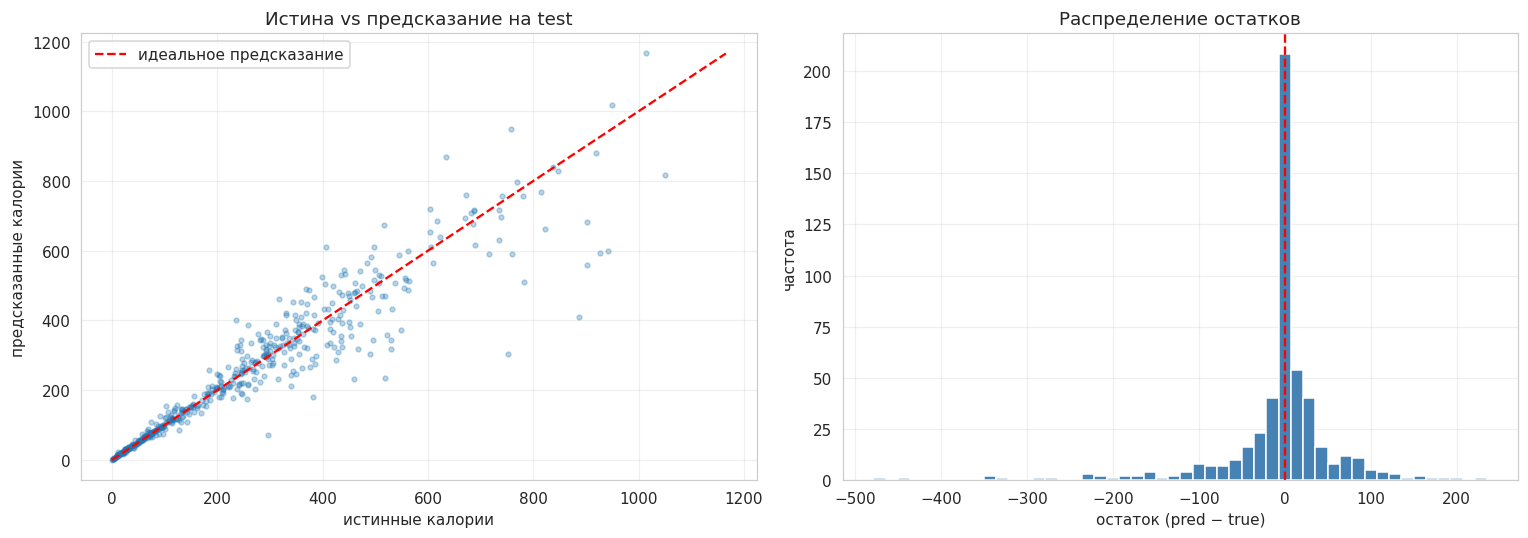

Средний остаток:  -5.36
Медиана остатков: 1.82
Std остатков:     68.80


In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(targets, preds, alpha=0.3, s=10)
lims = [0, max(targets.max(), preds.max())]
axes[0].plot(lims, lims, "r--", label="идеальное предсказание")
axes[0].set_xlabel("истинные калории")
axes[0].set_ylabel("предсказанные калории")
axes[0].set_title("Истина vs предсказание на test")
axes[0].legend()
axes[0].grid(alpha=0.3)

residuals = preds - targets
axes[1].hist(residuals, bins=50, color="steelblue", edgecolor="white")
axes[1].axvline(0, color="red", linestyle="--")
axes[1].set_xlabel("остаток (pred − true)")
axes[1].set_ylabel("частота")
axes[1].set_title("Распределение остатков")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Средний остаток:  {residuals.mean():.2f}")
print(f"Медиана остатков: {np.median(residuals):.2f}")
print(f"Std остатков:     {residuals.std():.2f}")